# Student Performance Factors: Hypothesis Testing

## Purpose

This notebook tests the project's three hypotheses using the cleaned
Student Performance Factors dataset.

The analysis focuses on:

1. Attendance and exam scores, accounting for study hours and previous scores.
2. Whether the association between tutoring and exam scores varies with
   previous scores.
3. Differences in exam scores across resource-access groups, accounting
   for other factors specified in the hypothesis plan.

## Approach

Each test will include:

- The research question and null and alternative hypotheses.
- The chosen method and why it is appropriate.
- Checks of the model assumptions.
- Results, including effect estimates and 95% confidence intervals.
- An interpretation linked to the research question and its limitations.

A significance level of 0.05 will be used, with Holm correction applied
to the three main hypothesis tests to account for multiple testing.

The results describe associations and do not establish causation.

## Import Libraries

These libraries support data loading, regression analysis, diagnostic
plots and adjustment for multiple hypothesis tests.

In [2]:
# File paths
from pathlib import Path

# Data handling and numerical calculations
import pandas as pd
import numpy as np

# Visualisations and diagnostic plots
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistical modelling and multiple-testing correction
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

## Load the Cleaned Dataset

The cleaned dataset is loaded from the project's data/processed folder.
The first five rows and dataset dimensions are displayed to confirm
that it has loaded correctly.

In [3]:
# Locate the cleaned dataset
data_path = (
    Path("..")
    / "data"
    / "processed"
    / "StudentPerformanceFactors_cleaned.csv"
)

# Load the data
df = pd.read_csv(data_path)

# Check the number of rows and columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Preview the first five rows
df.head()

Rows: 6,607
Columns: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Hypothesis 1: Attendance and Exam Scores

### Research Question

Is attendance associated with exam scores after accounting for
study hours and previous scores?

### Null Hypothesis (H₀)

Attendance has no linear association with exam scores after accounting
for study hours and previous scores.

The attendance coefficient in the regression model equals zero.

### Alternative Hypothesis (H₁)

Attendance has a linear association with exam scores after accounting
for study hours and previous scores.

The attendance coefficient in the regression model is not zero.

### Method and Justification

Multiple linear regression will be used because exam score is numerical
and the model can examine attendance, study hours and previous scores
together.

- Outcome: Exam_Score
- Main predictor: Attendance
- Adjustment variables: Hours_Studied and Previous_Scores

The attendance coefficient estimates the difference in expected exam
score associated with a one-percentage-point increase in attendance,
holding study hours and previous scores constant.

The significance level is α = 0.05. Final decisions for the three main
hypothesis tests will compare their Holm-adjusted p-values with 0.05.

This is a two-sided test. Model assumptions and influential observations
will be checked before drawing conclusions. The attendance p-value will
be included in the Holm correction across the three main hypothesis tests.

This analysis does not establish causation.

### Check the Variables

Before fitting the model, check that the four required columns are
numerical and contain no missing values. Review their ranges to identify
any values that need consideration when interpreting the results.

In [4]:
# Created with ChatGPT assistance for this project's analysis.

# Select the variables needed for Hypothesis 1
h1_columns = [
    "Exam_Score",
    "Attendance",
    "Hours_Studied",
    "Previous_Scores"
]

# Summarise data types, missing values and ranges
h1_checks = pd.DataFrame({
    "Data type": df[h1_columns].dtypes,
    "Missing values": df[h1_columns].isna().sum(),
    "Minimum": df[h1_columns].min(),
    "Maximum": df[h1_columns].max()
})

h1_checks

,Data type,Missing values,Minimum,Maximum
Exam_Score,int64,0,55,101
Attendance,int64,0,60,100
Hours_Studied,int64,0,1,44
Previous_Scores,int64,0,50,100


### Variable Check Findings

- All four variables are stored as integers and have no missing values.
- Attendance ranges from 60% to 100%.
- Hours studied range from 1 to 44.
- Previous scores range from 50 to 100.
- Exam scores range from 55 to 101.

The exam score of 101 remains an unresolved data-quality concern.
Following the cleaning decision, it will be retained in the main model.
A sensitivity analysis excluding scores above 100 will check whether
this decision affects the results.

### Fit the Regression Model

This model examines the association between attendance and exam scores,
while accounting for study hours and previous scores.

Ordinary least squares (OLS) estimates the regression coefficients.
HC3 robust standard errors are used to allow for unequal residual
variance. Model diagnostics will still be checked before interpreting
the results.

The p-values shown here are unadjusted. Holm correction will be applied
to the three main hypothesis tests once all have been completed.

### Choice of Regression Model and Justification

This analysis uses multiple linear regression, fitted using
ordinary least squares (OLS).

The outcome, Exam_Score, is a numerical score rather than a
category. Linear regression is appropriate for modelling how
the expected exam score varies with the predictors.

The model includes three predictors: Attendance, Hours_Studied
and Previous_Scores. Using multiple regression allows us to
estimate the association between attendance and exam scores
while holding study hours and previous scores constant.

Logistic regression is commonly used for categorical outcomes,
such as pass or fail. Our research question concerns the exam
score itself, so we have not converted scores into categories.

HC3 robust standard errors are used to allow for unequal
residual variance. Residual plots, influence checks and
sensitivity analysis help assess the model's limitations.
HC3 does not correct nonlinearity or remove influential
observations.

The results describe adjusted associations and do not
establish that attendance causes higher exam scores.

In [5]:
# Created with ChatGPT assistance for this project's analysis.

# Fit the model with HC3 robust standard errors
h1_model = smf.ols(
    formula="Exam_Score ~ Attendance + Hours_Studied + Previous_Scores",
    data=df
).fit(cov_type="HC3")

# Display the regression results
print(h1_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.572
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     2392.
Date:                Thu, 08 Oct 2026   Prob (F-statistic):               0.00
Time:                        11:01:09   Log-Likelihood:                -15546.
No. Observations:                6607   AIC:                         3.110e+04
Df Residuals:                    6603   BIC:                         3.113e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          41.9990      0.339    1

### Initial Regression Results

- The model includes all 6,607 observations.
- R-squared is 0.572: the three predictors together explain approximately
  57.2% of the variation in exam scores in this dataset.
- Holding study hours and previous scores constant, a 10-percentage-point
  increase in attendance is associated with approximately 1.99 additional
  exam-score points (95% confidence interval: 1.93 to 2.04).
- The attendance p-value is below 0.001. The displayed value of 0.000
  reflects rounding, rather than a probability of exactly zero.
- Study hours and previous scores also have positive coefficients.

### Checks Required Before the Final Conclusion

The residual statistics indicate substantial positive skew and heavy
tails. Residual plots and influential observations will therefore be
examined. HC3 robust standard errors do not resolve all model limitations.

The condition-number warning will also be investigated. It can reflect
predictor scaling and does not by itself establish multicollinearity.

The final hypothesis decision will follow diagnostic checks, the
sensitivity analysis and Holm correction. These results do not
establish causation.

### Diagnostic Check: Residuals vs Predicted Scores

This plot compares the model's predicted exam scores with its residuals
(actual scores minus predicted scores).

A residual above zero means the student scored higher than predicted.
A residual below zero means the student scored lower than predicted.

We look for residuals scattered around zero without a clear curve.
A widening or narrowing spread may indicate unequal residual variance.
Points far from zero identify predictions with large errors.

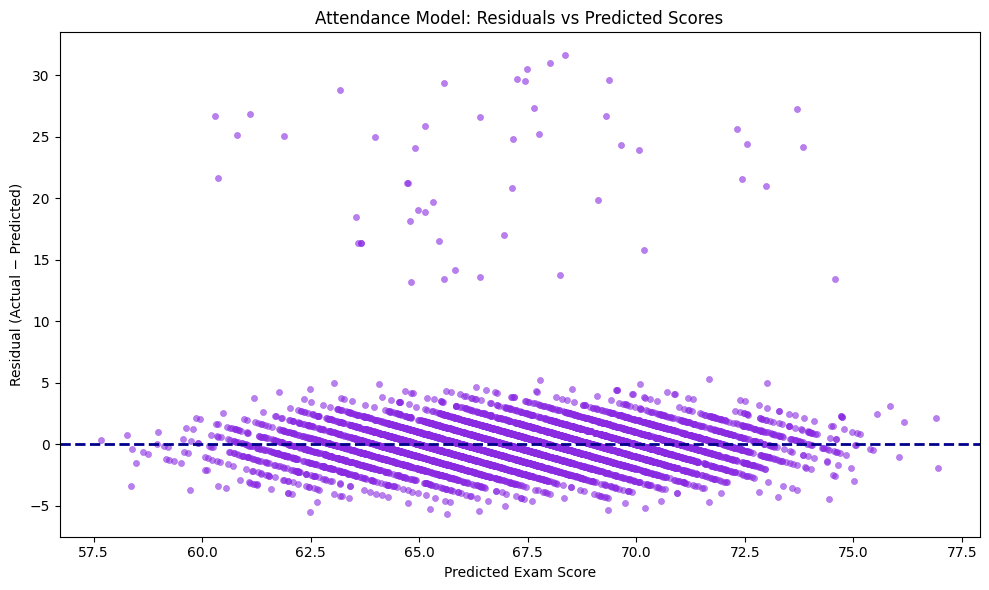

In [6]:
# Created with ChatGPT assistance for this project's analysis.
# Reference: Seaborn scatterplot documentation
# https://seaborn.pydata.org/generated/seaborn.scatterplot.html

# Plot model residuals against predicted exam scores
%matplotlib inline
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=h1_model.fittedvalues,
    y=h1_model.resid,
    color="blueviolet",
    alpha=0.6,
    s=20,
    edgecolor=None
)

# Add a reference line for zero prediction error
plt.axhline(y=0, color="darkblue", linestyle="--", linewidth=2)

# Add the title and axis labels
plt.title("Attendance Model: Residuals vs Predicted Scores")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual (Actual − Predicted)")
plt.tight_layout()

# Save and display the diagnostic chart
plt.savefig(
    "../visualisations/h1_residuals_vs_predicted.png",
    dpi=300
)
plt.show()

### Residual Plot Findings

- Most residuals fall approximately between -5 and +5 exam-score points.
- Several large positive residuals reach above 30 points, meaning the
  model substantially underpredicts some students' exam scores.
- These large positive errors are consistent with the positive skew
  reported in the regression summary.
- The diagonal bands arise because exam scores are whole numbers,
  while predicted scores vary continuously.
- There is no obvious curved pattern in the main cluster, but this
  plot alone does not confirm linearity or equal residual variance.
- The observations with large residuals require further investigation.
  A large residual does not necessarily mean an observation strongly
  influences the regression coefficients.

### Diagnostic Check: Normal Q–Q Plot

This plot compares the model's residuals with the values expected
under a normal distribution.

Points close to the reference line suggest approximate normality.
Departures from the line, particularly at the ends, indicate
differences in the tails or asymmetry.

This check helps assess the residual distribution; it does not
determine whether the relationship is causal.

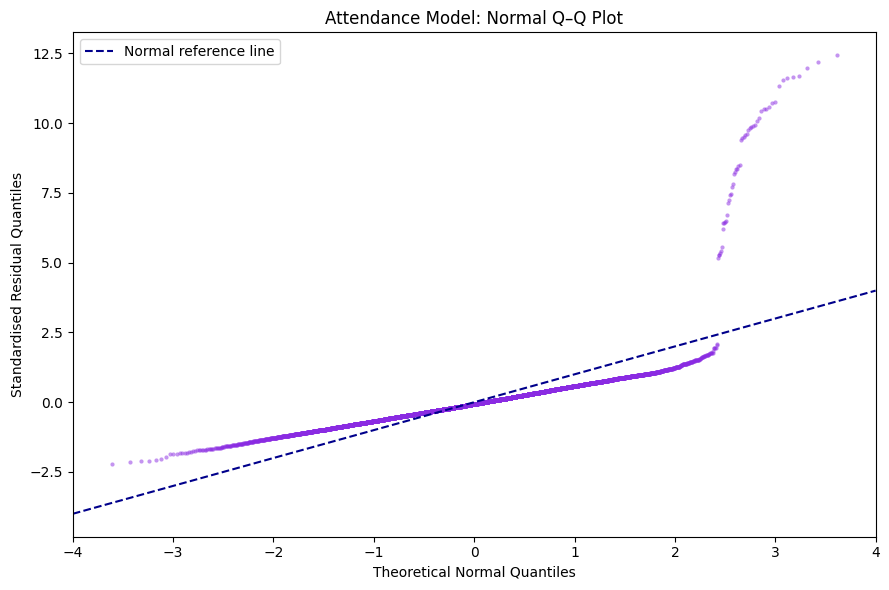

In [7]:
# Created with ChatGPT assistance for this project's analysis.
# Reference: Official statsmodels Q-Q plot documentation
# https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html

%matplotlib inline

# Plot residual quantiles using smaller dots
fig, ax = plt.subplots(figsize=(9, 6))
sm.qqplot(
    h1_model.resid,
    fit=True,
    line=None,
    ax=ax,
    marker="o",
    markersize=3,
    markerfacecolor="blueviolet",
    markeredgecolor="none",
    linestyle="none",
    alpha=0.5
)

# Draw the normal reference line across the theoretical quantile range
ax.plot(
    [-4, 4],
    [-4, 4],
    color="darkblue",
    linestyle="--",
    linewidth=1.5,
    label="Normal reference line"
)

# Focus the horizontal axis while retaining all residual points
ax.set_xlim(-4, 4)
ax.set_title("Attendance Model: Normal Q–Q Plot")
ax.set_xlabel("Theoretical Normal Quantiles")
ax.set_ylabel("Standardised Residual Quantiles")
ax.legend()
fig.tight_layout()

# Save and display the updated chart
fig.savefig("../visualisations/h1_qq_plot.png", dpi=300)
plt.show()

### Q–Q Plot Findings

- The residuals depart noticeably from the normal reference line,
  particularly in the upper tail.
- The large positive residuals indicate that some students scored
  much higher than the model predicted.
- The residual distribution is strongly right-skewed and is not
  approximately normal.
- This agrees with the residual scatter plot and regression summary.
- HC3 robust standard errors do not make the residuals normal or
  remove the potential influence of unusual observations.
- Influence checks and sensitivity analysis are needed before
  finalising the interpretation of the attendance association.

### Checking Influential Observations

The diagnostic plots showed some large positive residuals.
We will check whether individual observations have a strong
influence on the fitted regression model.

Cook’s distance combines the size of an observation’s residual
with its leverage, which measures how unusual its predictor
values are.

We will use Cook’s distance above 4/n as a screening guideline,
where n is the number of observations. Flagged observations
will be investigated, not automatically removed.

A large residual does not necessarily mean an observation
strongly influences the model.

In [8]:
# Created with ChatGPT assistance for this project's analysis.
# Sources: Official statsmodels documentation
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_influence.html
# https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html

# Calculate influence measures from the fitted attendance model
h1_influence = h1_model.get_influence()
h1_cooks_distance = h1_influence.cooks_distance[0]

# Use 4/n as a screening guideline, not a rule for removing rows
h1_cooks_threshold = 4 / h1_model.nobs

# Keep the original dataset indices for the observations in the model
h1_model_indices = h1_model.model.data.row_labels
h1_influence_table = df.loc[
    h1_model_indices,
    ["Exam_Score", "Attendance", "Hours_Studied", "Previous_Scores"]
].copy()

# Add diagnostic measures
h1_influence_table["Residual"] = np.asarray(h1_model.resid)
h1_influence_table["Leverage"] = h1_influence.hat_matrix_diag
h1_influence_table["Cooks_Distance"] = h1_cooks_distance
h1_influence_table["Flagged"] = (
    h1_influence_table["Cooks_Distance"] > h1_cooks_threshold
)

# Summarise the screening results without removing any observations
print(f"Observations checked: {int(h1_model.nobs):,}")
print(f"Cook's distance screening threshold: {h1_cooks_threshold:.6f}")
print(f"Flagged observations: {h1_influence_table['Flagged'].sum():,}")
print(f"Largest Cook's distance: {h1_cooks_distance.max():.6f}")

# Display the ten observations with the largest Cook's distances
h1_influence_table.sort_values(
    "Cooks_Distance", ascending=False
).head(10)

Observations checked: 6,607
Cook's distance screening threshold: 0.000605
Flagged observations: 77
Largest Cook's distance: 0.055953


,Exam_Score,Attendance,Hours_Studied,Previous_Scores,Residual,Leverage,Cooks_Distance,Flagged
4779,92,88,1,72,28.825566,0.001739,0.055953,True
2595,87,69,7,54,26.710042,0.001314,0.036268,True
3141,86,63,7,90,25.190263,0.001369,0.033612,True
1109,92,69,31,52,24.839236,0.001216,0.029033,True
1525,101,98,27,93,27.296876,0.000970,0.027931,True
6347,98,96,28,98,24.165974,0.001102,0.024882,True
2904,88,62,11,76,26.892949,0.000866,0.024207,True
529,97,83,15,97,29.566585,0.000629,0.021241,True
2687,87,71,11,55,25.104642,0.000872,0.021234,True
1351,82,61,9,77,21.624377,0.001081,0.019542,True


### Influence Check Findings

- Of the 6,607 observations, 77 exceeded the Cook’s distance
  screening threshold of approximately 0.000605.
- These flagged observations represent approximately 1.17%
  of the dataset.
- The largest Cook’s distance was approximately 0.056,
  belonging to the observation at dataset index 4779.
  Its exam score was about 28.83 points above the model prediction.
- The observation with an exam score of 101, at index 1525,
  was also flagged, with a Cook’s distance of approximately 0.028.
- All ten observations displayed had large positive residuals,
  consistent with the upper-tail departure in the Q–Q plot.
- This screening identifies observations for further investigation;
  it does not establish that they are errors or should be removed.
- All observations remain in the main model. Sensitivity checks
  will assess how much the attendance estimate changes under
  alternative inclusion decisions.

### Checking Multicollinearity

The regression summary reported a large condition number.
This can reflect differences in predictor scales or strong
relationships between predictors; it does not establish
multicollinearity by itself.

We will calculate the variance inflation factor (VIF) for
Attendance, Hours_Studied and Previous_Scores.

VIF measures how much a coefficient’s variance is inflated
because its predictor is related to the other predictors.
Values close to 1 indicate little overlap. Values above 5
will be treated as a guideline for further investigation,
rather than an automatic reason to remove a predictor.

The calculation will include the model’s intercept, but we
will report VIF values only for the three predictors.

In [9]:
# Created with ChatGPT assistance for this project's analysis.
# Source: Official statsmodels VIF documentation
# https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the fitted model's design matrix, including its intercept
h1_design_matrix = h1_model.model.exog
h1_predictor_names = h1_model.model.exog_names

# Calculate VIF for each predictor while retaining the intercept
# in the underlying calculations
h1_vif_table = pd.DataFrame(
    [
        {
            "Predictor": name,
            "VIF": variance_inflation_factor(h1_design_matrix, i)
        }
        for i, name in enumerate(h1_predictor_names)
        if name != "Intercept"
    ]
)

# Display the results to three decimal places
h1_vif_table.round(3)

,Predictor,VIF
0,Attendance,1.000
1,Hours_Studied,1.001
2,Previous_Scores,1.001


### Multicollinearity Findings

- VIF values were 1.000 for Attendance and 1.001 for both
  Hours_Studied and Previous_Scores, rounded to three decimals.
- These values indicate very little linear overlap between
  the three predictors.
- Multicollinearity is therefore not a concern in this model,
  and all three predictors will be retained.
- The large condition number in the regression summary does
  not appear to reflect strong multicollinearity. Predictor
  scales and their non-zero means can contribute to it.
- These results address multicollinearity only; they do not
  resolve the residual or influence concerns identified earlier.
  

### Sensitivity Analysis: Exam Score Above 100

The dataset contains an exam score of 101. We have retained
this observation because we cannot confirm whether it is an
error or a valid score under the original scoring system.

To assess its effect, we will refit the same multiple linear
regression using only observations with Exam_Score at or below
100, keeping the same predictors and HC3 robust standard errors.

We will compare the attendance coefficient and its 95%
confidence interval with those from the full-data model.

This is a sensitivity analysis, not a permanent removal.
The cleaned dataset and the original model remain unchanged.

In [10]:
# Created with ChatGPT assistance for this project's analysis.
# Source: Official statsmodels OLS fitting documentation
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

# Create a separate dataset for this sensitivity check
h1_data_max100 = df.loc[df["Exam_Score"] <= 100].copy()

# Refit the same model with HC3 robust standard errors
h1_model_max100 = smf.ols(
    formula="Exam_Score ~ Attendance + Hours_Studied + Previous_Scores",
    data=h1_data_max100
).fit(cov_type="HC3")

# Compare attendance estimates and 95% confidence intervals
h1_sensitivity_rows = []

for label, model in [
    ("Full dataset", h1_model),
    ("Exam scores at or below 100", h1_model_max100)
]:
    attendance_ci = model.conf_int().loc["Attendance"]

    h1_sensitivity_rows.append(
        {
            "Model": label,
            "Observations": int(model.nobs),
            "Attendance coefficient": model.params["Attendance"],
            "95% CI lower": attendance_ci.iloc[0],
            "95% CI upper": attendance_ci.iloc[1]
        }
    )

h1_sensitivity_table = pd.DataFrame(h1_sensitivity_rows)

# Report the percentage change relative to the original estimate
h1_attendance_change_pct = (
    (h1_model_max100.params["Attendance"]
     - h1_model.params["Attendance"])
    / h1_model.params["Attendance"]
    * 100
)

print(
    "Observations excluded for this check:",
    int(h1_model.nobs - h1_model_max100.nobs)
)
print(
    "Percentage change in attendance coefficient: "
    f"{h1_attendance_change_pct:.3f}%"
)

h1_sensitivity_table.round(4)

Observations excluded for this check: 1
Percentage change in attendance coefficient: -0.288%


,Model,Observations,Attendance coefficient,95% CI lower,95% CI upper
0,Full dataset,6607,0.1985,0.1933,0.2037
1,Exam scores at or below 100,6606,0.1979,0.1928,0.2030


### Sensitivity Analysis Findings

- Excluding the single exam score above 100 reduced the sample
  from 6,607 to 6,606 observations.
- The attendance coefficient changed from 0.1985 to 0.1979,
  a decrease of approximately 0.288%.
- The 95% confidence intervals were very similar:
  0.1933–0.2037 for the full model and 0.1928–0.2030
  for the sensitivity model. Both remained above zero.
- In both models, a 10-percentage-point increase in attendance
  was associated with approximately 1.98 additional exam-score
  points, holding study hours and previous scores constant.
- The estimated attendance association is therefore not
  materially dependent on the observation with a score of 101.
- The full-data model remains the main analysis. This check
  does not establish whether 101 is a valid score or address
  the combined influence of the other flagged observations.

### Sensitivity Analysis: Observations Flagged by Cook’s Distance

We will refit the same multiple linear regression after
temporarily excluding the 77 observations flagged by the
original model’s Cook’s distance screening threshold.

We will retain the same predictors and HC3 robust standard
errors, then compare the attendance coefficient and its
95% confidence interval with the full-data model.

This is an exploratory sensitivity check. The observations
were flagged using the model’s results, so excluding them
may introduce selection bias. The reduced model will not
replace the main analysis or determine our hypothesis decision.

Flagged observations are not necessarily errors. The cleaned
dataset and full-data model remain unchanged.

In [11]:
# Created with ChatGPT assistance for this project's analysis.
# Source: Official statsmodels OLS fitting documentation
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

# Select observations not flagged by the original model
h1_unflagged_indices = h1_influence_table.index[
    ~h1_influence_table["Flagged"]
]
h1_data_unflagged = df.loc[h1_unflagged_indices].copy()

# Refit the same model for this exploratory sensitivity check
h1_model_unflagged = smf.ols(
    formula="Exam_Score ~ Attendance + Hours_Studied + Previous_Scores",
    data=h1_data_unflagged
).fit(cov_type="HC3")

# Compare attendance estimates and 95% confidence intervals
h1_influence_comparison_rows = []

for label, model in [
    ("Full dataset", h1_model),
    ("Without Cook's distance flagged observations", h1_model_unflagged)
]:
    attendance_ci = model.conf_int().loc["Attendance"]

    h1_influence_comparison_rows.append(
        {
            "Model": label,
            "Observations": int(model.nobs),
            "Attendance coefficient": model.params["Attendance"],
            "95% CI lower": attendance_ci.iloc[0],
            "95% CI upper": attendance_ci.iloc[1]
        }
    )

h1_influence_comparison = pd.DataFrame(h1_influence_comparison_rows)

# Calculate the percentage change relative to the full model
h1_influence_change_pct = (
    (h1_model_unflagged.params["Attendance"]
     - h1_model.params["Attendance"])
    / h1_model.params["Attendance"]
    * 100
)

print(
    "Observations excluded for this check:",
    int(h1_model.nobs - h1_model_unflagged.nobs)
)
print(
    "Percentage change in attendance coefficient: "
    f"{h1_influence_change_pct:.3f}%"
)

h1_influence_comparison.round(4)

Observations excluded for this check: 77
Percentage change in attendance coefficient: 0.455%


,Model,Observations,Attendance coefficient,95% CI lower,95% CI upper
0,Full dataset,6607,0.1985,0.1933,0.2037
1,Without Cook's distance flagged observations,6530,0.1994,0.1961,0.2026


### Influence Sensitivity Findings

- Temporarily excluding the 77 flagged observations reduced
  the sample from 6,607 to 6,530 observations.
- The attendance coefficient increased from 0.1985 to 0.1994,
  a change of approximately 0.455%.
- The estimated association remained approximately two
  additional exam-score points per 10-percentage-point
  increase in attendance, holding the other predictors constant.
- The 95% confidence interval changed from 0.1933–0.2037
  to 0.1961–0.2026. Both intervals remained above zero.
- The attendance estimate was stable under this exclusion check.
  This does not establish that all model assumptions are satisfied.
- The narrower interval in the reduced model should not be
  interpreted as evidence of a better model, because observations
  were excluded using diagnostics from the original model.
- All observations remain in the main analysis. This exploratory
  check supports the stability of the attendance estimate but
  does not replace the full-data hypothesis test.

## H1: Adjusted Attendance and Predicted Exam Score

This chart will show the model’s expected exam score across the observed
attendance range, holding study hours and previous scores at their sample
means.

The shaded band will represent a 95% confidence interval for the expected
mean exam score, using the model’s HC3 robust covariance estimates.
It is not a prediction interval for an individual student.

The chart illustrates an adjusted association, not a causal effect.

In [15]:
# Created with assistance from ChatGPT.
# Sources:
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_prediction.html
# https://plotly.com/python/continuous-error-bars/

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# Vary attendance while holding both adjustment variables at their means.
h1_prediction_data = pd.DataFrame({
    "Attendance": np.linspace(
        df["Attendance"].min(),
        df["Attendance"].max(),
        100
    ),
    "Hours_Studied": df["Hours_Studied"].mean(),
    "Previous_Scores": df["Previous_Scores"].mean()
})

# Use the existing HC3 model to calculate pointwise 95% confidence
# intervals for the expected mean, not individual prediction intervals.
h1_predictions = h1_model.get_prediction(
    h1_prediction_data
).summary_frame(alpha=0.05)

h1_attendance_fig = go.Figure()

# Add the upper boundary first.
h1_attendance_fig.add_trace(go.Scatter(
    x=h1_prediction_data["Attendance"],
    y=h1_predictions["mean_ci_upper"],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip"
))

# Fill the area between the lower and upper boundaries.
h1_attendance_fig.add_trace(go.Scatter(
    x=h1_prediction_data["Attendance"],
    y=h1_predictions["mean_ci_lower"],
    mode="lines",
    line=dict(color="crimson", width=1.5, dash="dot"),
    fill="tonexty",
    fillcolor="rgba(220, 20, 60, 0.08)",
    name="95% CI for expected mean",
    hoverinfo="skip"
))

# Add the model's expected mean score.
h1_attendance_fig.add_trace(go.Scatter(
    x=h1_prediction_data["Attendance"],
    y=h1_predictions["mean"],
    mode="lines",
    line=dict(color="crimson", width=1.5, dash="dot"),
    name="Expected exam score",
    hovertemplate=(
        "Attendance: %{x:.1f}%<br>"
        "Expected exam score: %{y:.2f}<extra></extra>"
    )
))

h1_attendance_fig.update_layout(
    title=dict(
        text=(
            "Adjusted Attendance and Expected Exam Score"
            "<br><sup>Study hours and previous scores held "
            "at their sample means</sup>"
        )
    ),
    xaxis_title="Attendance (%)",
    yaxis_title="Expected exam score",
    template="plotly_white",
    height=500,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="left",
        x=0
    ),
    margin=dict(t=130)
)

# Save an interactive copy in the project's visualisations folder.
h1_visualisation_dir = Path("../visualisations")
h1_visualisation_dir.mkdir(parents=True, exist_ok=True)

h1_attendance_fig.write_html(
    h1_visualisation_dir / "h1_adjusted_attendance.html"
)

h1_attendance_fig.show()

### Findings: Adjusted Attendance and Expected Exam Score

Holding study hours and previous scores at their sample means, the
expected exam score increases from approximately 63.3 at 60% attendance
to 71.2 at 100% attendance.

A 10-percentage-point increase in attendance is associated with an
approximately 1.99-point increase in expected exam score.

The solid blue line shows the expected mean score. The red dotted
boundaries show its pointwise 95% confidence interval. These intervals
describe uncertainty in the estimated mean, not the range of scores
expected for individual students.

The straight line reflects the regression model’s assumed linear
relationship. These results show an adjusted association and do not
establish that higher attendance causes higher exam scores.

## H1 Summary

Attendance was positively associated with exam scores after adjusting
for study hours and previous scores.

The estimated attendance coefficient was 0.1985, with an HC3 robust
95% confidence interval of 0.1933–0.2037 and an unadjusted p-value
below 0.001. This corresponds to approximately 1.99 additional exam
score points per 10-percentage-point increase in attendance.

The model explained approximately 57.2% of the observed variation in
exam scores (R² = 0.572). This refers to all three predictors together,
not attendance alone.

Diagnostics identified substantial departures from residual normality
and some influential observations. VIF values near 1 indicated no
concerning multicollinearity among the predictors.

The attendance estimate changed by less than 0.5% in both sensitivity
checks: excluding the score above 100 and excluding the 77 observations
flagged by Cook’s distance. The full dataset remains the main analysis.

These checks support the stability of the attendance estimate, but do
not establish that all model assumptions hold or that the relationship
is causal.

The final hypothesis decision will be reported after applying the
Holm correction across all three main tests.


## Hypothesis 2: Tutoring and Previous Performance

### Research Question

Does the relationship between tutoring sessions and exam scores vary
with students’ previous scores?

### Null Hypothesis (H₀)

The relationship between tutoring sessions and exam scores does not
vary with previous scores. The interaction coefficient equals zero.

### Alternative Hypothesis (H₁)

The relationship between tutoring sessions and exam scores varies
with previous scores. The interaction coefficient is not zero.

### Method and Justification

Multiple linear regression will include tutoring sessions, previous
scores and their interaction. Exam score is the numerical outcome.

The interaction tests whether the expected difference in exam score
associated with one additional tutoring session changes as previous
scores increase.

Both predictors will be centred by subtracting their sample means.
This makes their main coefficients easier to interpret without changing
the fitted predictions or the interaction test.

HC3 robust standard errors will be used. We will examine residual
patterns, influential observations and multicollinearity, and consider
the assumption that observations are independent.

This is a two-sided test. The interaction p-value will be included
in the Holm correction across the three primary tests, using a
significance level of 0.05.

Results describe associations and do not establish causation.

### Check the H2 Variables

Check the data types, missing values and numerical ranges of tutoring
sessions, previous scores and exam scores before fitting the interaction
model.

In [16]:
# Created with assistance from ChatGPT.
# Check the variables needed for H2 without changing the dataset.

h2_columns = ["Tutoring_Sessions", "Previous_Scores", "Exam_Score"]

h2_checks = pd.DataFrame({
    "Data type": df[h2_columns].dtypes,
    "Missing values": df[h2_columns].isna().sum(),
    "Minimum": df[h2_columns].min(),
    "Maximum": df[h2_columns].max(),
    "Unique values": df[h2_columns].nunique()
})

display(h2_checks)

,Data type,Missing values,Minimum,Maximum,Unique values
Tutoring_Sessions,int64,0,0,8,9
Previous_Scores,int64,0,50,100,51
Exam_Score,int64,0,55,101,45


### Findings: H2 Variable Checks

All three variables are stored as integers and contain no missing values.

- Tutoring sessions range from 0 to 8, with 9 distinct values.
- Previous scores range from 50 to 100, with 51 distinct values.
- Exam scores range from 55 to 101, with 45 distinct values.

The exam score of 101 was identified earlier. Its validity remains
unconfirmed, so it will be retained in the main analysis and its
effect on H2 will be examined through a sensitivity check.

No rows need to be excluded because of missing values in these variables.

### Fit the H2 Interaction Model

An ordinary least squares (OLS) multiple linear regression will model
exam scores using centred tutoring sessions, centred previous scores
and their interaction.

The interaction coefficient measures how the tutoring–exam score
association changes for each one-point increase in previous scores.

HC3 robust standard errors will be used for confidence intervals and
p-values. These allow for unequal error variance but do not resolve
an incorrect model form or dependence between observations.

In [17]:
# Created with assistance from ChatGPT.
# Sources:
# https://www.statsmodels.org/stable/example_formulas.html
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

import statsmodels.formula.api as smf

# Work on a separate copy, keeping df unchanged.
h2_data = df[
    ["Tutoring_Sessions", "Previous_Scores", "Exam_Score"]
].copy()

# Store the means for later interpretation and visualisation.
h2_tutoring_mean = h2_data["Tutoring_Sessions"].mean()
h2_previous_mean = h2_data["Previous_Scores"].mean()

# Centre each predictor around its sample mean.
h2_data["Tutoring_Centred"] = (
    h2_data["Tutoring_Sessions"] - h2_tutoring_mean
)
h2_data["Previous_Centred"] = (
    h2_data["Previous_Scores"] - h2_previous_mean
)

# Include both main terms and their interaction.
h2_model = smf.ols(
    formula="Exam_Score ~ Tutoring_Centred * Previous_Centred",
    data=h2_data
).fit(cov_type="HC3")

# Retain the unrounded interaction p-value for the later Holm correction.
h2_interaction_term = "Tutoring_Centred:Previous_Centred"
h2_p_value = h2_model.pvalues[h2_interaction_term]

print(h2_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     119.3
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           3.17e-75
Time:                        11:29:36   Log-Likelihood:                -18160.
No. Observations:                6607   AIC:                         3.633e+04
Df Residuals:                    6603   BIC:                         3.636e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

### Initial Findings: H2 Interaction Model

The model included 6,607 observations and explained approximately
5.6% of the observed variation in exam scores (R² = 0.056).

The interaction coefficient was approximately -0.0007, with an HC3
robust 95% confidence interval of approximately -0.006 to 0.005.
Its unadjusted p-value was 0.805.

These initial results provide no evidence that the linear association
between tutoring sessions and exam scores varies with previous scores.
They do not prove that the interaction is exactly zero.

At the sample mean of previous scores, one additional tutoring session
was associated with approximately 0.50 additional exam score points
(95% confidence interval: 0.427–0.578).

The residual summary indicates positive skew and heavy tails.
Diagnostic plots and sensitivity checks will be examined before
drawing conclusions. HC3 standard errors do not resolve every
potential model limitation.

The final H2 decision will use the Holm-adjusted interaction p-value.
These results describe associations, not causal effects.

### H2 Diagnostic Check: Residuals Against Predicted Scores

Residuals are the differences between observed and predicted exam scores.

This plot will help identify curvature, changes in residual spread and
unusually large prediction errors. A suitable linear model should show
residuals scattered around zero without a clear systematic pattern.

HC3 robust standard errors allow for unequal error variance, but do not
correct an unsuitable model form.

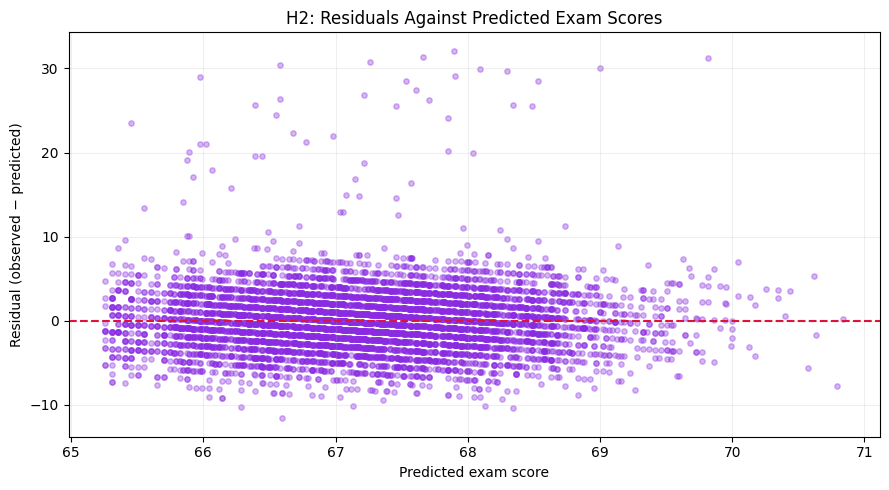

In [18]:
# Created with assistance from ChatGPT.
# Source:
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html

import matplotlib.pyplot as plt
from pathlib import Path

# Plot residuals from the fitted H2 model.
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    h2_model.fittedvalues,
    h2_model.resid,
    color="blueviolet",
    alpha=0.35,
    s=15
)

ax.axhline(0, color="crimson", linestyle="--", linewidth=1.5)

ax.set_title("H2: Residuals Against Predicted Exam Scores")
ax.set_xlabel("Predicted exam score")
ax.set_ylabel("Residual (observed − predicted)")
ax.grid(alpha=0.2)

fig.tight_layout()

# Save the diagnostic chart.
Path("../visualisations").mkdir(parents=True, exist_ok=True)
fig.savefig(
    "../visualisations/h2_residuals_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Findings: H2 Residual Plot

Most residuals lie approximately between -10 and +10, with several
large positive residuals reaching above +30. The model substantially
underpredicts exam scores for these observations.

The diagonal bands arise because exam scores are integers:
observations with the same exam score follow the relationship
residual = observed score − predicted score.

There is no obvious strong curve in the main cloud of points.
However, this visual check does not establish that the linear model
is correctly specified or that residual variance is constant.
There are also fewer observations at the highest predicted scores.

The large positive residuals are consistent with the positive skew
reported in the model summary. Further checks will examine the
residual distribution and whether influential observations affect
the interaction estimate.

### H2 Diagnostic Check: Q–Q Plot

This plot compares standardised model residuals with theoretical normal
quantiles. Points close to the reference line indicate approximate
agreement with a normal distribution.

Departures from the line, particularly in the tails, indicate departures
from normality. This check concerns the residuals, not the predictors
or exam scores themselves.

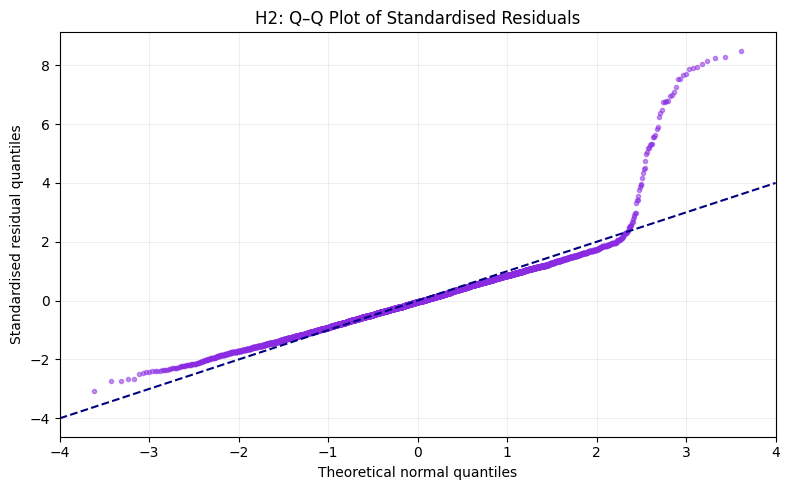

In [19]:
# Created with assistance from ChatGPT.
# Source:
# https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html

import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(8, 5))

# Standardise residuals and show individual points without joining them.
sm.qqplot(
    h2_model.resid,
    fit=True,
    line=None,
    ax=ax,
    marker="o",
    markersize=3,
    markerfacecolor="blueviolet",
    markeredgecolor="blueviolet",
    alpha=0.5,
    linestyle="None"
)

# Add the normal-distribution reference line.
ax.plot(
    [-4, 4],
    [-4, 4],
    color="navy",
    linestyle="--",
    linewidth=1.5
)

ax.set_xlim(-4, 4)
ax.set_title("H2: Q–Q Plot of Standardised Residuals")
ax.set_xlabel("Theoretical normal quantiles")
ax.set_ylabel("Standardised residual quantiles")
ax.grid(alpha=0.2)

fig.tight_layout()
fig.savefig(
    "../visualisations/h2_qq_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Findings: H2 Q–Q Plot

The central residuals lie reasonably close to the normal reference
line, but the upper tail departs sharply upwards. The largest
standardised residuals exceed 8.

This indicates a heavy positive tail: some observed exam scores are
much higher than the model predicts. The lower tail also departs
from the reference line, but less dramatically.

Overall, the residual distribution is not approximately normal.
This agrees with the positive skew and large positive residuals
identified in the earlier checks.

HC3 robust standard errors do not make the residuals normal or
eliminate the potential influence of unusual observations.
We will examine influence and sensitivity before finalising
the interpretation of the interaction estimate.

### H2 Diagnostic Check: Influential Observations

Cook’s distance measures how strongly an observation affects the
overall fitted regression model.

Observations with Cook’s distance above 4/n will be flagged for review.
This is a screening guideline, not a rule for deleting observations
or proof that a value is incorrect.

We will inspect the flagged observations and later check whether
excluding them changes the interaction estimate. The full dataset
will remain the main analysis.

In [20]:
# Created with assistance from ChatGPT.
# Sources:
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_influence.html
# https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.OLSInfluence.html

# Calculate influence measures for the H2 model.
h2_influence = h2_model.get_influence()
h2_cooks_distance = h2_influence.cooks_distance[0]
h2_cooks_threshold = 4 / h2_model.nobs

# Preserve the original row labels for observations used in the model.
h2_model_indices = h2_model.model.data.row_labels

h2_influence_table = h2_data.loc[
    h2_model_indices,
    ["Tutoring_Sessions", "Previous_Scores", "Exam_Score"]
].copy()

h2_influence_table["Residual"] = h2_model.resid
h2_influence_table["Leverage"] = h2_influence.hat_matrix_diag
h2_influence_table["Cooks_Distance"] = h2_cooks_distance
h2_influence_table["Flagged"] = (
    h2_influence_table["Cooks_Distance"] > h2_cooks_threshold
)

# Report the number flagged and inspect the largest Cook's distances.
h2_flagged_count = int(h2_influence_table["Flagged"].sum())
h2_flagged_pct = 100 * h2_flagged_count / h2_model.nobs

print(f"Cook's distance threshold: {h2_cooks_threshold:.6f}")
print(f"Flagged observations: {h2_flagged_count} ({h2_flagged_pct:.2f}%)")

display(
    h2_influence_table.sort_values(
        "Cooks_Distance", ascending=False
    ).head(10)
)

Cook's distance threshold: 0.000605
Flagged observations: 250 (3.78%)


,Tutoring_Sessions,Previous_Scores,Exam_Score,Residual,Leverage,Cooks_Distance,Flagged
1525,5,93,101,31.186656,0.003452,0.059119,True
3579,4,86,99,30.000416,0.001213,0.019139,True
4192,0,91,98,30.736586,0.000808,0.013374,True
4531,0,95,93,25.541119,0.001060,0.012122,True
217,0,54,89,23.544651,0.001203,0.011688,True
3932,4,55,84,16.432264,0.002299,0.010905,True
6347,1,98,98,29.907427,0.000614,0.009622,True
3124,0,90,94,26.785452,0.000754,0.009476,True
2040,7,93,63,-7.794223,0.007924,0.008553,True
529,2,97,97,28.467863,0.000589,0.008364,True


### Findings: H2 Influential Observations

Using the screening threshold of 4/n = 0.000605, 250 observations
(3.78% of the dataset) were flagged as potentially influential.

The largest Cook’s distance was approximately 0.0591 at index 1525.
This observation had 5 tutoring sessions, a previous score of 93
and an exam score of 101. Its residual was approximately +31.19,
meaning the observed score was substantially higher than predicted.

Many of the highest-ranked observations had large positive residuals.
However, influence also depends on predictor values. For example,
index 2040 had a smaller residual of approximately -7.79 but relatively
high leverage, with 7 tutoring sessions and a previous score of 93.

These flags do not establish that observations are incorrect or
should be removed. Cook’s distance concerns the overall model,
rather than the interaction coefficient alone.

All observations will remain in the main analysis. Sensitivity checks
will examine how excluding the score above 100 and, separately, the
flagged observations affects the interaction estimate.

### H2 Diagnostic Check: Multicollinearity

Variance inflation factors (VIFs) will assess linear overlap among
the centred predictors and their interaction term.

Values close to 1 indicate little overlap. Higher values indicate
greater inflation of coefficient variance due to multicollinearity.

The intercept will be included in the VIF calculations, but only
the predictor results will be reported.

In [21]:
# Created with assistance from ChatGPT.
# Source:
# https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the model's design matrix, including its intercept.
h2_design_matrix = h2_model.model.exog
h2_term_names = h2_model.model.exog_names

# Calculate VIFs for the predictors and interaction.
h2_vif_table = pd.DataFrame([
    {
        "Predictor": term,
        "VIF": variance_inflation_factor(h2_design_matrix, i)
    }
    for i, term in enumerate(h2_term_names)
    if term != "Intercept"
])

display(h2_vif_table.round(3))

,Predictor,VIF
0,Tutoring_Centred,1.001
1,Previous_Centred,1.000
2,Tutoring_Centred:Previous_Centred,1.001


### Findings: H2 Multicollinearity Check

VIF values were 1.001 for centred tutoring sessions, 1.000 for centred
previous scores and 1.001 for their interaction.

These values indicate very little linear overlap among the model terms.
There is no evidence of concerning multicollinearity in this model.

This check does not resolve the residual distribution or influential
observation concerns identified earlier.

### H2 Sensitivity Check: Excluding the Score Above 100

The interaction model will be refitted after excluding the exam score
above 100. Its interaction coefficient, HC3 confidence interval and
unadjusted p-value will be compared with the full model.

The original centring values will be retained for consistency.
The full model remains the main analysis; this check does not change
the cleaned dataset or replace the p-value used for Holm correction.

In [22]:
# Created with assistance from ChatGPT.
# Source:
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

# Create a separate subset, retaining the existing centred columns.
h2_data_max100 = h2_data.loc[
    h2_data["Exam_Score"] <= 100
].copy()

# Refit the same interaction model with HC3 robust standard errors.
h2_model_max100 = smf.ols(
    formula="Exam_Score ~ Tutoring_Centred * Previous_Centred",
    data=h2_data_max100
).fit(cov_type="HC3")

# Compare the interaction estimates without overwriting the main model.
h2_sensitivity_rows = []

for label, model in [
    ("Full dataset", h2_model),
    ("Exam score <= 100", h2_model_max100)
]:
    interaction_ci = model.conf_int().loc[h2_interaction_term]

    h2_sensitivity_rows.append({
        "Model": label,
        "Observations": int(model.nobs),
        "Interaction coefficient": model.params[h2_interaction_term],
        "95% CI lower": interaction_ci.iloc[0],
        "95% CI upper": interaction_ci.iloc[1],
        "Unadjusted p-value": model.pvalues[h2_interaction_term]
    })

h2_sensitivity_table = pd.DataFrame(h2_sensitivity_rows)
display(h2_sensitivity_table.round(6))

,Model,Observations,Interaction coefficient,95% CI lower,95% CI upper,Unadjusted p-value
0,Full dataset,6607,-0.000669,-0.005976,0.004637,0.804677
1,Exam score <= 100,6606,-0.001592,-0.006592,0.003407,0.532482


### Findings: H2 Sensitivity Check for the Score Above 100

Excluding the observation with an exam score of 101 reduced the sample
from 6,607 to 6,606 observations.

The interaction coefficient changed from -0.000669 to -0.001592.
The HC3 95% confidence interval changed from [-0.005976, 0.004637]
to [-0.006592, 0.003407].

The unadjusted p-value changed from 0.804677 to 0.532482.
Both confidence intervals include zero, and neither model provides
evidence of an interaction at the unadjusted 0.05 significance level.

The observation affects the numerical estimate, but excluding it
does not change this initial interpretation. This does not prove
that the interaction is absent.

The full model remains the main analysis, and its original interaction
p-value will be used for the Holm correction.

The 250 flagged observations are individual student rows, representing
3.78% of the dataset. They were flagged because their prediction errors,
their combinations of tutoring sessions and previous scores, or both,
give them greater potential influence on the fitted model.

These rows are not necessarily errors. They will be temporarily excluded
only from a separate sensitivity model to check how their removal changes
the tutoring × previous-score interaction estimate. This comparison will
use 6,357 observations. The cleaned dataset and main H2 model will retain
all 6,607 observations.

### H2 Sensitivity Check: Excluding Flagged Observations

Cook’s distance flagged 250 student rows (3.78% of the dataset) as
potentially influential because of their prediction errors, predictor
values, or both. These observations are not necessarily mistakes.

A separate model will temporarily exclude these rows, leaving 6,357
observations. Its tutoring × previous-score interaction coefficient,
HC3 confidence interval and unadjusted p-value will be compared with
the full model to assess sensitivity to these observations.

The original centring values will be retained. This is an exploratory
check: removing flagged observations does not automatically improve
the model, and a narrower confidence interval would not prove that
the result is more reliable.

The cleaned dataset and main H2 model will retain all 6,607 observations.
The full model’s interaction p-value will be used for the Holm correction.

In [23]:
# Created with assistance from ChatGPT.
# Source:
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

# Select observations not flagged by the original H2 influence check.
h2_unflagged_indices = h2_influence_table.index[
    ~h2_influence_table["Flagged"]
]

# Keep the original centred columns and leave h2_data unchanged.
h2_data_unflagged = h2_data.loc[h2_unflagged_indices].copy()

h2_model_unflagged = smf.ols(
    formula="Exam_Score ~ Tutoring_Centred * Previous_Centred",
    data=h2_data_unflagged
).fit(cov_type="HC3")

# Compare the interaction term in the full and sensitivity models.
h2_influence_rows = []

for label, model in [
    ("Full dataset", h2_model),
    ("Without Cook's flagged observations", h2_model_unflagged)
]:
    interaction_ci = model.conf_int().loc[h2_interaction_term]

    h2_influence_rows.append({
        "Model": label,
        "Observations": int(model.nobs),
        "Interaction coefficient": model.params[h2_interaction_term],
        "95% CI lower": interaction_ci.iloc[0],
        "95% CI upper": interaction_ci.iloc[1],
        "Unadjusted p-value": model.pvalues[h2_interaction_term]
    })

h2_influence_comparison = pd.DataFrame(h2_influence_rows)
display(h2_influence_comparison.round(6))

,Model,Observations,Interaction coefficient,95% CI lower,95% CI upper,Unadjusted p-value
0,Full dataset,6607,-0.000669,-0.005976,0.004637,0.804677
1,Without Cook's flagged observations,6357,-0.001694,-0.005580,0.002192,0.392806


### Findings: H2 Sensitivity to Flagged Observations

Temporarily excluding the 250 student rows flagged by Cook’s distance
reduced the sample from 6,607 to 6,357 observations.

The interaction coefficient changed from -0.000669 to -0.001694.
Its HC3 95% confidence interval changed from [-0.005976, 0.004637]
to [-0.005580, 0.002192].

The unadjusted p-value decreased from 0.804677 to 0.392806. Both
confidence intervals include zero, and neither model provides evidence
at the unadjusted 0.05 level that the tutoring–exam score association
varies with previous scores.

The numerical estimate is affected by these observations, but their
exclusion does not change this initial interpretation. This does not
prove that the interaction is absent.

The narrower confidence interval does not establish that the reduced
model is better: observations were excluded using the original model’s
diagnostics, making this an exploratory sensitivity check.

All 6,607 observations remain in the cleaned dataset and main H2 model.
The full model’s interaction p-value will be used for Holm correction.

### Check Tutoring Counts Before Visualising H2

Count the observations at each tutoring-session value and calculate
the lower quartile, median and upper quartile of previous scores.

These three previous-score values will provide representative settings
for the interaction chart. Tutoring counts will identify values where
predictions have less data support. These counts alone do not establish
support for every combination of tutoring sessions and previous scores.

In [24]:
# Created with assistance from ChatGPT.
# Inspect the data supporting the planned H2 interaction chart.

h2_tutoring_counts = (
    h2_data["Tutoring_Sessions"]
    .value_counts()
    .sort_index()
    .rename_axis("Tutoring sessions")
    .reset_index(name="Number of students")
)

h2_previous_quantiles = h2_data["Previous_Scores"].quantile(
    [0.25, 0.50, 0.75]
)

display(h2_tutoring_counts)
print("Previous-score quartiles:")
display(h2_previous_quantiles.rename("Previous score"))

,Tutoring sessions,Number of students
0,0,1513
1,1,2179
2,2,1649
3,3,836
4,4,301
5,5,103
6,6,18
7,7,7
8,8,1


Previous-score quartiles:


0.25    63.0
0.50    75.0
0.75    88.0
Name: Previous score, dtype: float64

### Findings: Data Support for the H2 Chart

Tutoring-session counts are concentrated between 0 and 5 sessions,
covering 6,581 of the 6,607 students (approximately 99.6%).

Only 18 students had 6 sessions, 7 had 7 sessions and 1 had 8 sessions.
Predictions at these higher values therefore have limited data support.

The lower quartile, median and upper quartile of previous scores
are 63, 75 and 88. The interaction chart will show model predictions
at these three representative values, across 0–5 tutoring sessions.

These curves will represent predictions at fixed previous scores,
not observed averages for three student groups. The counts do not
guarantee equally strong support for every predictor combination.

Restricting the displayed range does not change the fitted model,
which continues to use all 6,607 observations.

### H2 Visualisation: Tutoring and Previous Scores

This chart will show expected exam scores across 0–5 tutoring sessions
at previous scores of 63, 75 and 88, using the full interaction model.

Each line represents predictions at a fixed previous score. Error bars
show pointwise 95% confidence intervals for the expected mean, calculated
using the model’s HC3 robust covariance estimates.

Similar slopes indicate a small estimated interaction. The formal
interaction test, rather than confidence-interval overlap, will be used
to assess evidence that the slopes differ.

These are model predictions, not individual student outcomes or
evidence of a causal effect of tutoring.

In [26]:
# Created with assistance from ChatGPT.
# Sources:
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLSResults.get_prediction.html
# https://plotly.com/python/error-bars/


h2_interaction_fig = go.Figure()

# Use representative previous scores and distinct visual styles.
h2_chart_settings = [
    (63, "Previous score: 63 (lower quartile)", "blueviolet", "solid"),
    (75, "Previous score: 75 (median)", "darkorange", "dash"),
    (88, "Previous score: 88 (upper quartile)", "teal", "dot")
]

for previous_score, label, colour, line_style in h2_chart_settings:
    # Apply the same centring values used to fit the full model.
    prediction_data = pd.DataFrame({
        "Tutoring_Centred": np.arange(6) - h2_tutoring_mean,
        "Previous_Centred": previous_score - h2_previous_mean
    })

    predictions = h2_model.get_prediction(
        prediction_data
    ).summary_frame(alpha=0.05)

    h2_interaction_fig.add_trace(go.Scatter(
        x=np.arange(6),
        y=predictions["mean"],
        mode="lines+markers",
        name=label,
        line=dict(color=colour, width=2, dash=line_style),
        marker=dict(size=7),
        error_y=dict(
            type="data",
            symmetric=False,
            array=predictions["mean_ci_upper"] - predictions["mean"],
            arrayminus=predictions["mean"] - predictions["mean_ci_lower"],
            color=colour,
            thickness=1.2,
            width=4
        ),
        hovertemplate=(
            "Tutoring sessions: %{x}<br>"
            "Expected exam score: %{y:.2f}<extra>%{fullData.name}</extra>"
        )
    ))

h2_interaction_fig.update_layout(
    title=dict(
        text=(
            "Tutoring and Expected Exam Score"
            "<br><sup>At three previous scores; error bars show "
            "95% confidence intervals for the expected mean</sup>"
        )
    ),
    xaxis_title="Tutoring sessions",
    yaxis_title="Expected exam score",
    template="plotly_white",
    height=550,
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.22,
        xanchor="left",
        x=0
    ),
    margin=dict(t=100, b=130)
)

h2_interaction_fig.update_xaxes(dtick=1)

# Save the interactive chart.
Path("../visualisations").mkdir(parents=True, exist_ok=True)
h2_interaction_fig.write_html(
    "../visualisations/h2_tutoring_interaction.html"
)

h2_interaction_fig.show()

### Findings: H2 Interaction Chart

Expected exam scores increase with tutoring sessions at each of the
three previous-score values shown: 63, 75 and 88.

The lines are nearly parallel. This illustrates the small estimated
interaction: the tutoring–exam score association changes very little
across these previous-score values. The formal interaction test gave
an unadjusted p-value of approximately 0.805.

Higher previous scores are associated with higher expected exam scores
at each displayed tutoring level. These lines are model predictions
at fixed previous scores, not observed averages for student groups.

The error bars show pointwise 95% confidence intervals for the expected
mean score, not prediction intervals for individual students.
They generally widen towards the higher tutoring values.

The chart displays 0–5 sessions because observations above this range
are sparse. The fitted model still includes all 6,607 observations.

These associations do not establish that tutoring causes higher scores.
The final interaction decision will use the Holm-adjusted p-value.

## H2 Summary

The analysis examined whether the association between tutoring sessions
and exam scores varies with previous scores, using multiple linear
regression with an interaction term and HC3 robust standard errors.

The interaction coefficient was -0.000669, with a 95% confidence
interval of [-0.005976, 0.004637] and an unadjusted p-value of 0.804677.
This provides no evidence of a linear interaction in this model,
but does not prove that the interaction is absent.

At the sample mean of previous scores, one additional tutoring session
was associated with approximately 0.50 additional exam score points.
The nearly parallel lines in the interaction chart illustrate how
little this estimated association varies across previous scores
of 63, 75 and 88.

The model explained approximately 5.6% of the observed variation in
exam scores. Diagnostics showed a heavy positive residual tail and
250 potentially influential observations. VIF values near 1 indicated
no concerning multicollinearity.

Neither excluding the score of 101 nor separately excluding the
250 flagged observations changed the initial interpretation:
both sensitivity models had interaction confidence intervals
containing zero and unadjusted p-values above 0.05.

The full dataset remains the main analysis. The final hypothesis
decision will use the Holm-adjusted interaction p-value.

The model includes tutoring, previous scores and their interaction.
Other factors, such as attendance and study hours, were not included
in this planned H2 model. Its associations should not be interpreted
as causal effects.

## Hypothesis 3: Access to Resources and Exam Performance

### Research Question

Do expected exam scores differ across Low, Medium and High
resource-access groups after accounting for family income and
previous scores?

### Null Hypothesis (H₀)

Adjusted mean exam scores are equal across all three resource-access
groups, accounting for family income and previous scores.

### Alternative Hypothesis (H₁)

At least one resource-access group has a different adjusted mean
exam score, accounting for these factors.

### Method and Justification

Multiple linear regression using ordinary least squares (OLS) will
be used because exam score is numerical.

- Outcome: Exam_Score
- Main predictor: Access_to_Resources, treated as categorical
- Adjustment variables: Family_Income, treated as categorical,
  and Previous_Scores, treated as numerical

Treating the categories separately avoids assuming equally spaced
differences between Low, Medium and High.

An overall Wald test using HC3 robust covariance estimates will jointly
test whether the resource-access coefficients are zero. This provides
one primary p-value for H3.

The model assumes a common linear association with previous scores
across groups and additive resource-access and family-income effects.
Residual patterns, influential observations and multicollinearity will
be examined. Independence of observations will also be considered.

The overall H3 p-value will be included in the Holm correction across
the three primary tests, using a significance level of 0.05.

These results describe adjusted associations and do not establish
causation.

### Check the H3 Variables

Check data types and missing values for the four H3 variables.
Inspect resource-access and family-income categories, including
the number of students in each combination.

Check the numerical ranges of previous scores and exam scores.
These checks will help identify unexpected categories or sparse
combinations before fitting the model.

In [ ]:
# Official pandas documentation:
# Data types:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dtypes.html

# Missing values:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html

# Unique-value counts:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html

# Category frequencies:
# https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

# Cross-tabulation:
# https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html

# Minimum and maximum aggregation:
# https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html

# Created with assistance from ChatGPT.

# Check H3 variables without changing the original dataset.
h3_columns = [
    "Access_to_Resources",
    "Family_Income",
    "Previous_Scores",
    "Exam_Score"
]

h3_checks = pd.DataFrame({
    "Data type": df[h3_columns].dtypes,
    "Missing values": df[h3_columns].isna().sum(),
    "Unique values": df[h3_columns].nunique()
})

display(h3_checks)

# Show all category labels and their counts.
for column in ["Access_to_Resources", "Family_Income"]:
    print(f"\n{column}:")
    display(df[column].value_counts(dropna=False))

# Inspect how many students appear in each category combination.
print("\nResource access by family income:")
display(pd.crosstab(
    df["Access_to_Resources"],
    df["Family_Income"]
))

# Check numerical ranges.
print("\nNumerical ranges:")
display(
    df[["Previous_Scores", "Exam_Score"]]
    .agg(["min", "max"])
    .T
)

,Data type,Missing values,Unique values
Access_to_Resources,object,0,3
Family_Income,object,0,3
Previous_Scores,int64,0,51
Exam_Score,int64,0,45



Access_to_Resources:


Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


Family_Income:


Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64


Resource access by family income:


Family_Income,High,Low,Medium
Access_to_Resources,,,
High,381,831,763
Low,238,533,542
Medium,650,1308,1361



Numerical ranges:


,min,max
Previous_Scores,50,100
Exam_Score,55,101


### Findings: H3 Variable Checks

All four H3 variables contain no missing values. Resource access and
family income are stored as text, each with three categories:
Low, Medium and High. Previous scores and exam scores are integers.

Resource-access group sizes are:
- Low: 1,313 students
- Medium: 3,319 students
- High: 1,975 students

Family-income group sizes are:
- Low: 2,672 students
- Medium: 2,666 students
- High: 1,269 students

All nine resource-access and family-income combinations are represented,
with counts ranging from 238 to 1,361. There are no empty or very small
cells in this cross-tabulation, although group sizes are unequal.

Previous scores range from 50 to 100, while exam scores range from
55 to 101. The previously identified score of 101 will remain in the
main analysis, with its effect examined through a sensitivity check.

No rows need to be excluded because of missing values in these variables.
Resource access and family income will be treated as categorical
predictors in the regression model.

### Fit the H3 Adjusted Group Model

An OLS multiple linear regression will model exam scores using
resource access, family income and previous scores.

Low will be the reference category for both categorical predictors.
The Medium and High resource-access coefficients will therefore
estimate differences from the Low group, holding family income
and previous scores constant.

Previous scores will be centred at their sample mean. This makes
the intercept interpretable as the expected exam score for a student
with Low resource access, Low family income and an average previous
score.

HC3 robust standard errors will be used. After fitting the model,
a joint Wald test will assess the overall resource-access hypothesis.
Individual coefficient p-values will not replace this overall test.

In [28]:
# Created with assistance from ChatGPT.
# References:
# https://www.statsmodels.org/stable/example_formulas.html
# https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.fit.html

# Work on a separate copy, leaving df unchanged.
h3_data = df[h3_columns].copy()

# Centre previous scores using the full sample mean.
h3_previous_mean = h3_data["Previous_Scores"].mean()
h3_data["Previous_Centred"] = (
    h3_data["Previous_Scores"] - h3_previous_mean
)

# Explicitly treat resource access and income as categorical,
# with Low as the reference category for each.
h3_formula = (
    'Exam_Score ~ C(Access_to_Resources, Treatment(reference="Low"))'
    ' + C(Family_Income, Treatment(reference="Low"))'
    ' + Previous_Centred'
)

h3_model = smf.ols(
    formula=h3_formula,
    data=h3_data
).fit(cov_type="HC3")

print(h3_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     97.85
Date:                Thu, 08 Oct 2026   Prob (F-statistic):          8.46e-100
Time:                        15:29:26   Log-Likelihood:                -18119.
No. Observations:                6607   AIC:                         3.625e+04
Df Residuals:                    6601   BIC:                         3.629e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

### Initial Findings: H3 Adjusted Group Model

The model included 6,607 observations and explained approximately
6.8% of the observed variation in exam scores (R² = 0.068).
This refers to all predictors together, not resource access alone.

Holding family income and previous scores constant:
- High resource access was associated with an expected exam score
  1.84 points higher than Low access
  (HC3 95% confidence interval: 1.586–2.097).
- Medium resource access was associated with an expected exam score
  0.88 points higher than Low access
  (HC3 95% confidence interval: 0.648–1.108).

Both comparisons had unadjusted p-values below 0.001. The displayed
0.000 values reflect rounding, not p-values of exactly zero.

The model summary indicates positive residual skew and heavy tails.
Diagnostic plots and sensitivity checks will be examined before
finalising the interpretation.

The overall resource-access hypothesis will be assessed using a
joint Wald test of both resource-access coefficients. Its p-value,
rather than the model-wide F-test p-value, will enter the Holm
correction across the three primary hypotheses.

These results describe adjusted associations and do not establish
causation.